In [129]:
### 0. IMPORTAÇÃO DE BIBLIOTECAS ###
import pandas as pd
import numpy as np
import unicodedata
import re
import sys
from rapidfuzz import fuzz, process, utils
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Executável do Python: {sys.executable}')

Executável do Python: C:\Users\luish\anaconda3\envs\bs_questionario\python.exe


In [130]:
### 1. FUNÇÕES DE LIMPEZA E CARGA DOS DADOS BRUTOS ###

## limpeza e normalizacao de textos (preserva numeros e remove acentos)
def limpar_texto(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = unicodedata.normalize('NFKD', x).encode('ASCII', 'ignore').decode('utf-8')
    x = re.sub(r'\s+', ' ', x)
    return x

## carregar o arquivo excel principal (questionario)
df = pd.read_excel(r"C:\Users\luish\Downloads\Desenvolvimento TCC\TCC\01 - Dados Brutos\Primarios\base_questionario_v1.xlsx")

## carregar o arquivo mapeamento de bairros - apenas a planilha bairros_oficiais
mapa_df = pd.read_excel(r"C:\Users\luish\Downloads\Desenvolvimento TCC\TCC\04 - Python\Tratamento Questionario\mapa_bairros.xlsx", sheet_name="bairros_oficiais")

## normaliza colunas do mapa de bairros oficiais
mapa_df['bairro_oficial_norm'] = mapa_df['bairro_oficial'].apply(limpar_texto)

## lista oficial de bairros extraida da planilha2
bairros_oficiais = mapa_df['bairro_oficial_norm'].dropna().unique().tolist()

print("--- Lista de Bairros Oficiais Carregada com Sucesso! ---")
print(f"Total de bairros cadastrados na Planilha2: {len(bairros_oficiais)}")
print(f'Dataset Principal carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.')

--- Lista de Bairros Oficiais Carregada com Sucesso! ---
Total de bairros cadastrados na Planilha2: 43
Dataset Principal carregado: 200 linhas e 23 colunas.


In [131]:
### 2. EXPLORAÇÃO E DIAGNÓSTICO INICIAL DOS DADOS ###
display(df.head())

diagnostico = pd.DataFrame({
    'coluna': df.columns,
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'nulos_%': (df.isna().mean() * 100).round(2),
    'unicos': df.nunique(),
})
display(diagnostico)

,ID,Hora de início,Hora de conclusão,Email,Nome,Hora da última modificação,Você concorda em participar desta pesquisa acadêmica de forma anônima?,Em qual bairro você mora?,"Informe um ponto de referência próximo à sua residência (rua, estabelecimento, etc.)",Qual sua faixa etária?,...,Com que frequência utiliza esses serviços?,Onde costuma realizar esses serviços?,Qual o gasto médio mensal com esses serviços?,Você teria interesse em serviços de estética integrativa (beleza + saúde)?,Quais serviços você teria interesse?,Qual o valor você estaria disposto(a) a pagar por sessão?,Qual a distância máxima que você estaria disposto(a) a percorrer para atendimento?,Qual seu principal meio de transporte?,Qual fator mais influência sua escolha por um serviço de estética?,Você gostaria que existisse uma clínica desse tipo próximo à sua residência?
0,12,2026-04-25 16:11:37,2026-04-25 16:15:24,anonymous,NaN,NaN,Sim,Cidade Jardim,Santa Lolla,26 a 35 anos,...,NaN,NaN,NaN,Talvez,"Terapias integrativas (relaxamento, bem estar)...",Acima de R$200,1 e 3 km,Carro,Qualidade do serviço,Sim
1,13,2026-04-25 16:18:34,2026-04-25 16:21:36,anonymous,NaN,NaN,Sim,Jardim tropical 1,NaN,26 a 35 anos,...,Raramente,Outro Bairro,Acima de R$300,"Sim, com certeza","Tratamento faciais (anti-idade, rejuvenescimen...",Acima de R$200,Mais de 5 km,Carro,Preço,Não
2,14,2026-04-25 16:21:22,2026-04-25 16:22:24,anonymous,NaN,NaN,Sim,cidade nova,rua A,26 a 35 anos,...,NaN,NaN,NaN,"Sim, com certeza",Limpeza de pele;Tratamento faciais (anti-idade...,R$100 a R$200,1 e 3 km,Carro,Qualidade do serviço,Sim
3,15,2026-04-25 16:20:54,2026-04-25 16:22:53,anonymous,NaN,NaN,Sim,Cidade Jardim,HB20 construção,36 a 45 anos,...,NaN,NaN,NaN,Talvez,Limpeza de pele;,R$100 a R$200,Mais de 5 km,Carro,Qualidade do serviço,Sim
4,16,2026-04-25 16:26:44,2026-04-25 16:28:22,anonymous,NaN,NaN,Sim,Popular 2,Projeto PIPA,46 anos ou mais,...,Raramente,Centro da cidade,R$100 a R$300,"Sim, com certeza",Limpeza de pele;Tratamento faciais (anti-idade...,Acima de R$200,1 e 3 km,Carro,Qualidade do serviço,Sim


,coluna,tipo,nulos,nulos_%,unicos
ID,ID,int64,0,0.0,200
Hora de início,Hora de início,datetime64[us],0,0.0,199
Hora de conclusão,Hora de conclusão,datetime64[us],0,0.0,200
Email,Email,str,0,0.0,1
Nome,Nome,float64,200,100.0,0
Hora da última modificação,Hora da última modificação,float64,200,100.0,0
Você concorda em participar desta pesquisa acadêmica de forma anônima?,Você concorda em participar desta pesquisa aca...,str,0,0.0,1
Em qual bairro você mora?,Em qual bairro você mora?,str,0,0.0,97
"Informe um ponto de referência próximo à sua residência (rua, estabelecimento, etc.)",Informe um ponto de referência próximo à sua r...,str,25,12.5,175
Qual sua faixa etária?,Qual sua faixa etária?,str,0,0.0,4


In [132]:
### 2.1. REMOÇÃO DE COLUNAS IRRELEVANTES (PÓS-DIAGNÓSTICO) ###

colunas_para_remover = [
    'Email', 
    'Nome', 
    'Hora da última modificação',
]

## remove as colunas originais antes da padronizacao de nomenclatura
df = df.drop(columns=colunas_para_remover, errors='ignore')

print(f"Colunas removidas com sucesso! Novo formato do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Colunas removidas com sucesso! Novo formato do dataset: 200 linhas e 20 colunas.


In [133]:
### 3. PADRONIZAÇÃO E NORMALIZAÇÃO DE NOMES DAS COLUNAS ###
def normalizar_nome_coluna(col):
    col = str(col).strip().lower()
    col = unicodedata.normalize('NFKD', col).encode('ASCII', 'ignore').decode('utf-8')
    col = re.sub(r'[^a-z0-9]+', '_', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col

df.columns = [normalizar_nome_coluna(c) for c in df.columns]
df.columns.tolist()

['id',
 'hora_de_inicio',
 'hora_de_conclusao',
 'voce_concorda_em_participar_desta_pesquisa_academica_de_forma_anonima',
 'em_qual_bairro_voce_mora',
 'informe_um_ponto_de_referencia_proximo_a_sua_residencia_rua_estabelecimento_etc',
 'qual_sua_faixa_etaria',
 'qual_o_seu_genero',
 'qual_sua_renda_mensal_aproximada',
 'voce_utiliza_ou_ja_utilizou_servicos_de_estetica',
 'com_que_frequencia_utiliza_esses_servicos',
 'onde_costuma_realizar_esses_servicos',
 'qual_o_gasto_medio_mensal_com_esses_servicos',
 'voce_teria_interesse_em_servicos_de_estetica_integrativa_beleza_saude',
 'quais_servicos_voce_teria_interesse',
 'qual_o_valor_voce_estaria_disposto_a_a_pagar_por_sessao',
 'qual_a_distancia_maxima_que_voce_estaria_disposto_a_a_percorrer_para_atendimento',
 'qual_seu_principal_meio_de_transporte',
 'qual_fator_mais_influencia_sua_escolha_por_um_servico_de_estetica',
 'voce_gostaria_que_existisse_uma_clinica_desse_tipo_proximo_a_sua_residencia']

In [134]:
### 3.1. RENOMEAÇÃO EM MASSA PARA O FORMATO CURTO (PADRÃO QGIS) ###

df = df.rename(columns={
    'qual_o_seu_genero': 'genero',
    'qual_sua_faixa_etaria': 'faixa_etaria',
    'em_qual_bairro_voce_mora': 'bairro',
    'qual_sua_renda_mensal_aproximada': 'renda',
    'voce_teria_interesse_em_servicos_de_estetica_integrativa_beleza_saude': 'interesse_estetica',
    'voce_concorda_em_participar_desta_pesquisa_academica_de_forma_anonima': 'termo_aceite',
    'informe_um_ponto_de_referencia_proximo_a_sua_residencia_rua_estabelecimento_etc': 'pt_referencia',
    'voce_utiliza_ou_ja_utilizou_servicos_de_estetica': 'usa_estetica',
    'com_que_frequencia_utiliza_esses_servicos': 'freq_estetica',
    'onde_costuma_realizar_esses_servicos': 'local_estetica',
    'qual_o_gasto_medio_mensal_com_esses_servicos': 'gasto_estetica',
    'quais_servicos_voce_teria_interesse': 'servicos_desejados',
    'qual_o_valor_voce_estaria_disposto_a_a_pagar_por_sessao': 'valor_disposto',
    'qual_a_distancia_maxima_que_voce_estaria_disposto_a_a_percorrer_para_atendimento': 'dist_maxima',
    'qual_seu_principal_meio_de_transporte': 'transporte',
    'qual_fator_mais_influencia_sua_escolha_por_um_servico_de_estetica': 'fator_influencia',
    'voce_gostaria_que_existisse_uma_clinica_desse_tipo_proximo_a_sua_residencia': 'clinica_perto'
})

print("--- Colunas renomeadas para o padrão curto com sucesso! ---")
df.columns.tolist()

--- Colunas renomeadas para o padrão curto com sucesso! ---


['id',
 'hora_de_inicio',
 'hora_de_conclusao',
 'termo_aceite',
 'bairro',
 'pt_referencia',
 'faixa_etaria',
 'genero',
 'renda',
 'usa_estetica',
 'freq_estetica',
 'local_estetica',
 'gasto_estetica',
 'interesse_estetica',
 'servicos_desejados',
 'valor_disposto',
 'dist_maxima',
 'transporte',
 'fator_influencia',
 'clinica_perto']

In [135]:
### 4. TRATAMENTO DE RAMIFICAÇÃO (SUBSTITUIR NaN POR NÃO SE APLICA) ###  

## lista com as colunas que ficam vazias quando a pessoa responde "nao"
colunas_dependente_estetica = [
    'freq_estetica',
    'local_estetica',
    'gasto_estetica',
    'valor_disposto',
    'dist_maxima',
    'transporte',
    'fator_influencia',
]

## preenche os valores nulos dessas colunas especificas com "nao se aplica"
df[colunas_dependente_estetica] = df[colunas_dependente_estetica].fillna("nao se aplica")

print("Valores nulos por ramificação tratados com 'nao se aplica'!")
df.columns.tolist()

Valores nulos por ramificação tratados com 'nao se aplica'!


['id',
 'hora_de_inicio',
 'hora_de_conclusao',
 'termo_aceite',
 'bairro',
 'pt_referencia',
 'faixa_etaria',
 'genero',
 'renda',
 'usa_estetica',
 'freq_estetica',
 'local_estetica',
 'gasto_estetica',
 'interesse_estetica',
 'servicos_desejados',
 'valor_disposto',
 'dist_maxima',
 'transporte',
 'fator_influencia',
 'clinica_perto']

In [136]:
### 4.1. CRIAÇÃO DAS COLUNAS DUMMY ESSENCIAIS ###

## limpa os textos da coluna clinica_perto antes de aplicar a regra
df['clinica_perto'] = df['clinica_perto'].apply(limpar_texto)

# criacao da dummy: 1 para sim, 0 para nao (ou outros valores)
df['d_clinica_perto'] = (df['clinica_perto'] == 'sim').astype(int)

## criacao da dummy de interesse maximo em estetica
df['interesse_estetica'] = df['interesse_estetica'].apply(limpar_texto)
df['int_maximo'] = (df['interesse_estetica'] == 'sim, com certeza').astype(int)

In [137]:
### 4.2. DIAGNÓSTICO E VALIDAÇÃO PÓS-RAMIFICAÇÃO ###

display(df.head())

diagnostico = pd.DataFrame({
    'coluna': df.columns,
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'nulos_%': (df.isna().mean() * 100).round(2),
    'unicos': df.nunique(),
})
display(diagnostico)

,id,hora_de_inicio,hora_de_conclusao,termo_aceite,bairro,pt_referencia,faixa_etaria,genero,renda,usa_estetica,...,gasto_estetica,interesse_estetica,servicos_desejados,valor_disposto,dist_maxima,transporte,fator_influencia,clinica_perto,d_clinica_perto,int_maximo
0,12,2026-04-25 16:11:37,2026-04-25 16:15:24,Sim,Cidade Jardim,Santa Lolla,26 a 35 anos,Masculino,1 a 3 sálarios mínimos,Não,...,nao se aplica,talvez,"Terapias integrativas (relaxamento, bem estar)...",Acima de R$200,1 e 3 km,Carro,Qualidade do serviço,sim,1,0
1,13,2026-04-25 16:18:34,2026-04-25 16:21:36,Sim,Jardim tropical 1,NaN,26 a 35 anos,Masculino,Acima de 5 salários mínimos,Sim,...,Acima de R$300,"sim, com certeza","Tratamento faciais (anti-idade, rejuvenescimen...",Acima de R$200,Mais de 5 km,Carro,Preço,nao,0,1
2,14,2026-04-25 16:21:22,2026-04-25 16:22:24,Sim,cidade nova,rua A,26 a 35 anos,Masculino,3 a 5 sálarios mínimos,Não,...,nao se aplica,"sim, com certeza",Limpeza de pele;Tratamento faciais (anti-idade...,R$100 a R$200,1 e 3 km,Carro,Qualidade do serviço,sim,1,1
3,15,2026-04-25 16:20:54,2026-04-25 16:22:53,Sim,Cidade Jardim,HB20 construção,36 a 45 anos,Feminino,3 a 5 sálarios mínimos,Não,...,nao se aplica,talvez,Limpeza de pele;,R$100 a R$200,Mais de 5 km,Carro,Qualidade do serviço,sim,1,0
4,16,2026-04-25 16:26:44,2026-04-25 16:28:22,Sim,Popular 2,Projeto PIPA,46 anos ou mais,Masculino,3 a 5 sálarios mínimos,Sim,...,R$100 a R$300,"sim, com certeza",Limpeza de pele;Tratamento faciais (anti-idade...,Acima de R$200,1 e 3 km,Carro,Qualidade do serviço,sim,1,1


,coluna,tipo,nulos,nulos_%,unicos
id,id,int64,0,0.0,200
hora_de_inicio,hora_de_inicio,datetime64[us],0,0.0,199
hora_de_conclusao,hora_de_conclusao,datetime64[us],0,0.0,200
termo_aceite,termo_aceite,str,0,0.0,1
bairro,bairro,str,0,0.0,97
pt_referencia,pt_referencia,str,25,12.5,175
faixa_etaria,faixa_etaria,str,0,0.0,4
genero,genero,str,0,0.0,3
renda,renda,str,0,0.0,4
usa_estetica,usa_estetica,str,0,0.0,2


In [138]:
### 5. CORREÇÃO DIFUSA DE BAIRROS (FUZZY) E EXPANSÃO DE MULTIPLA ESCOLHA ###

## limpar todas as colunas de texto do dataframe principal
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].apply(limpar_texto)

## dicionario de transicao (regra de negocio manual para o Habitar Feliz)
DE_PARA_BAIRROS = {
    "amec vile": "habitar feliz",
    "amec ville": "habitar feliz",
    "popular 1": "habitar feliz",
    "popular 2": "habitar feliz",
    "popular 01": "habitar feliz",
    "popular 02": "habitar feliz",
    "popular i": "habitar feliz",
    "popular ii": "habitar feliz",
    "popular I": "habitar feliz",
    "popular II": "habitar feliz",
}

## funcao para tratar excecoes e aplicar busca fuzzy
def corrigir_nome(nome):
    if pd.isna(nome) or str(nome).strip() == "" or str(nome).strip() == "nan":
        return "nao informado"

    nome_norm = limpar_texto(nome)

    # regra rigida: verifica a transicao para 'habitar feliz'
    if nome_norm in DE_PARA_BAIRROS:
        return DE_PARA_BAIRROS[nome_norm]
    
    # busca fuzzy (fuzzy match) contra a lista oficial da Planilha2
    resultado = process.extractOne(
        nome_norm,
        bairros_oficiais,
        scorer=fuzz.WRatio,
        processor=utils.default_process,
        score_cutoff=70  # mantido em 70 conforme seu parametro original
    )
    if resultado:
        return resultado[0] 

    return nome_norm
    
## aplicar correcao fuzzy de bairros
df["bairro_padronizado"] = df["bairro"].apply(corrigir_nome)
print("\nProcessamento de bairros concluído!")

print("\n--- Distribuição dos Bairros Padronizados ---")
display(df["bairro_padronizado"].value_counts().to_frame())

print("\n--- Amostra de Comparação (Antes x Depois) ---")
tamanho_amostra = min(20, len(df))
display(df[["bairro", "bairro_padronizado"]].sample(tamanho_amostra))

if 'servicos_desejados' in df.columns:
    # o separador do Microsoft Forms costuma ser virgula ou ponto e virgula.
    # conforme vimos na imagem anterior, suas respostas estao separadas por ";" ou por "/"
    # vamos usar o caractere correto de corte (ajuste para o seu caso se necessario)
    dummies_servicos = df['servicos_desejados'].str.get_dummies(sep=';').add_prefix('s_')
    
    # padroniza os nomes das novas colunas
    dummies_servicos.columns = [normalizar_nome_coluna(c) for c in dummies_servicos.columns]
    
    # junta de volta no dataframe principal
    df = pd.concat([df, dummies_servicos], axis=1)
    print("--- Colunas de serviços desmembradas para o MCDA! ---")


corrigidos = df[df["bairro"] != df["bairro_padronizado"]]
print(f"\nTotal de registros corrigidos / alterados: {len(corrigidos)}")

## exportacao final corrigida
df.to_excel("base_questionario_corrigido.xlsx", index=False)
print("Arquivo 'base_questionario_corrigido.xlsx' salvo com sucesso!")


Processamento de bairros concluído!

--- Distribuição dos Bairros Padronizados ---


,count
bairro_padronizado,
cidade jardim,21
da paz,19
primavera,17
habitar feliz,14
uniao,12
tropical,11
liberdade i,11
parque dos carajas,11
cidade nova,10



--- Amostra de Comparação (Antes x Depois) ---


,bairro,bairro_padronizado
191,nova carajas,nova carajas
90,amec vile,habitar feliz
124,liberdade 2,liberdade i
4,popular 2,habitar feliz
30,vila nova,nova vida
181,parque dos carajas,parque dos carajas
149,habitar feliz,habitar feliz
141,rio verde,rio verde
130,caetanopolis,caetanopolis
193,cidade jardim,cidade jardim


--- Colunas de serviços desmembradas para o MCDA! ---

Total de registros corrigidos / alterados: 48
Arquivo 'base_questionario_corrigido.xlsx' salvo com sucesso!


In [139]:
### 6. CRIAÇÃO DA MATRIZ DO MCDA E CONSOLIDAÇÃO POR BAIRRO - (PADRÃO QGIS) ###

## cria uma coluna binaria para o interesse máximo (publico alvo principal)
df['int_maximo'] = (df['interesse_estetica'] == 'sim, com certeza').astype(int)

## identifica automaticamente todas as colunas de serviços criadas pelo dummies
colunas_servicos = [col for col in df.columns if col.startswith('s_')]

## agrupa as respostas por bairro usando nomes super curtos (max 10 caracteres)
matriz_mcda = df.groupby('bairro_padronizado').agg(
    tot_entrv=('bairro', 'count'),            # total de entrevistados no bairro
    cli_potnc=('int_maximo', 'sum'),          # volume absoluto de clientes potenciais
    clin_perto=('d_clinica_perto', 'sum'),    # volume absoluto de pessoas que querem a clinica perto
    **{servico: (servico, 'sum') for servico in colunas_servicos}
).reset_index()

## calcula a taxa de interesse relativo (%) por bairro
matriz_mcda['tx_int_pa'] = ((matriz_mcda['cli_potnc'] / matriz_mcda['tot_entrv']) * 100).round(2)
matriz_mcda['tx_cl_pert'] = ((matriz_mcda['clin_perto'] / matriz_mcda['tot_entrv']) * 100).round(2)

### DICIONÁRIO DE ABREVIAÇÕES EXCLUSIVAS PARA O QGIS (APENAS OS 8 CRITÉRIOS DA TABELA 5) ###

dicionario_mapa_colunas = {
    's_depilacao_a_laser': 's_depil_ls',
    's_limpeza_de_pele': 's_limp_pl',
    's_procedimentos_minimamente_invasivos': 's_pcd_inv',
    's_terapias_integrativas_relaxamento_bem_estar': 's_terapias',
    's_tratamento_de_enzima_para_retirar_gordura': 's_ptc_corp',
    's_tratamento_faciais_anti_idade_rejuvenescimento': 's_ptc_face'
}

## renomeia as colunas selecionadas
matriz_mcda = matriz_mcda.rename(columns=dicionario_mapa_colunas)

## COLUNAS FINAIS DO MODELO MCDA (Exclui manicure, pedicure, harmonização isolada, etc.)
colunas_finais_mcda = [
    'bairro_padronizado', 'tot_entrv', 'cli_potnc', 'clin_perto',
    'tx_int_pa', 'tx_cl_pert',
    's_limp_pl', 's_pcd_inv', 's_terapias', 
    's_ptc_corp', 's_ptc_face', 's_depil_ls'
]

## filtra a matriz mantendo apenas as colunas de interesse do TCC
matriz_mcda = matriz_mcda[[col for col in colunas_finais_mcda if col in matriz_mcda.columns]]

print("--- Matriz do MCDA Gerada e Alinhada com a Tabela 5! ---")
display(matriz_mcda.head(15))

## exporta a matriz consolidada
matriz_mcda.to_excel(r"C:\Users\luish\Downloads\Desenvolvimento TCC\TCC\02 - Dados Tratados\matriz_final_mcda_bairros.xlsx", index=False)
print("Arquivo 'matriz_final_mcda_bairros.xlsx' salvo com sucesso!")

--- Matriz do MCDA Gerada e Alinhada com a Tabela 5! ---


,bairro_padronizado,tot_entrv,cli_potnc,clin_perto,tx_int_pa,tx_cl_pert,s_limp_pl,s_pcd_inv,s_terapias,s_ptc_corp,s_ptc_face,s_depil_ls
0,altamira,7,7,6,100.00,85.71,6,2,4,0,4,0
1,alvora,1,1,1,100.00,100.00,1,1,1,0,1,0
2,amazonia,1,1,1,100.00,100.00,1,1,0,0,0,0
3,apoena,5,3,4,60.00,80.00,5,2,1,0,3,0
4,beira rio,6,6,6,100.00,100.00,6,2,3,0,4,0
5,bela vista,2,1,2,50.00,100.00,1,0,0,0,2,0
6,betania,3,1,1,33.33,33.33,0,0,0,0,0,0
7,caetanopolis,3,2,3,66.67,100.00,2,0,1,0,1,0
8,cidade jardim,21,14,18,66.67,85.71,16,4,13,0,8,0
9,cidade nova,10,8,8,80.00,80.00,6,1,7,0,5,0


Arquivo 'matriz_final_mcda_bairros.xlsx' salvo com sucesso!


In [140]:
### 7. TABELA DE CONTINGÊNCIA E CRUZAMENTO DE VARIÁVEIS ###

## cruzamento de bairro padronizado com o interesse em estética 
cross_bairro_interesse = pd.crosstab(
    df['bairro_padronizado'], 
    df['interesse_estetica'], 
    normalize='index'
) * 100

print("\n--- Porcentagem de Interesse em Estética por Bairro ---")
display(cross_bairro_interesse.round(2))


--- Porcentagem de Interesse em Estética por Bairro ---


interesse_estetica,nao tenho interesse,"sim, com certeza",talvez
bairro_padronizado,,,
altamira,0.00,100.00,0.00
alvora,0.00,100.00,0.00
amazonia,0.00,100.00,0.00
apoena,0.00,60.00,40.00
beira rio,0.00,100.00,0.00
bela vista,0.00,50.00,50.00
betania,66.67,33.33,0.00
caetanopolis,0.00,66.67,33.33
cidade jardim,9.52,66.67,23.81


In [141]:
### 7.1. FREQUÊNCIAS ABSOLUTAS E TOTAIS DE INTERESSE POR BAIRRO ###

## cruzamento mostrando a quantidade exata de pessoas
cross_bairro_contagem = pd.crosstab(
    df['bairro_padronizado'], 
    df['interesse_estetica'],
    margins=True,
    margins_name="Total"
)

print("\n--- Quantidade Real de Entrevistados por Bairro e Interesse ---")
display(cross_bairro_contagem)


--- Quantidade Real de Entrevistados por Bairro e Interesse ---


interesse_estetica,nao tenho interesse,"sim, com certeza",talvez,Total
bairro_padronizado,,,,
altamira,0,7,0,7
alvora,0,1,0,1
amazonia,0,1,0,1
apoena,0,3,2,5
beira rio,0,6,0,6
bela vista,0,1,1,2
betania,2,1,0,3
caetanopolis,0,2,1,3
cidade jardim,2,14,5,21


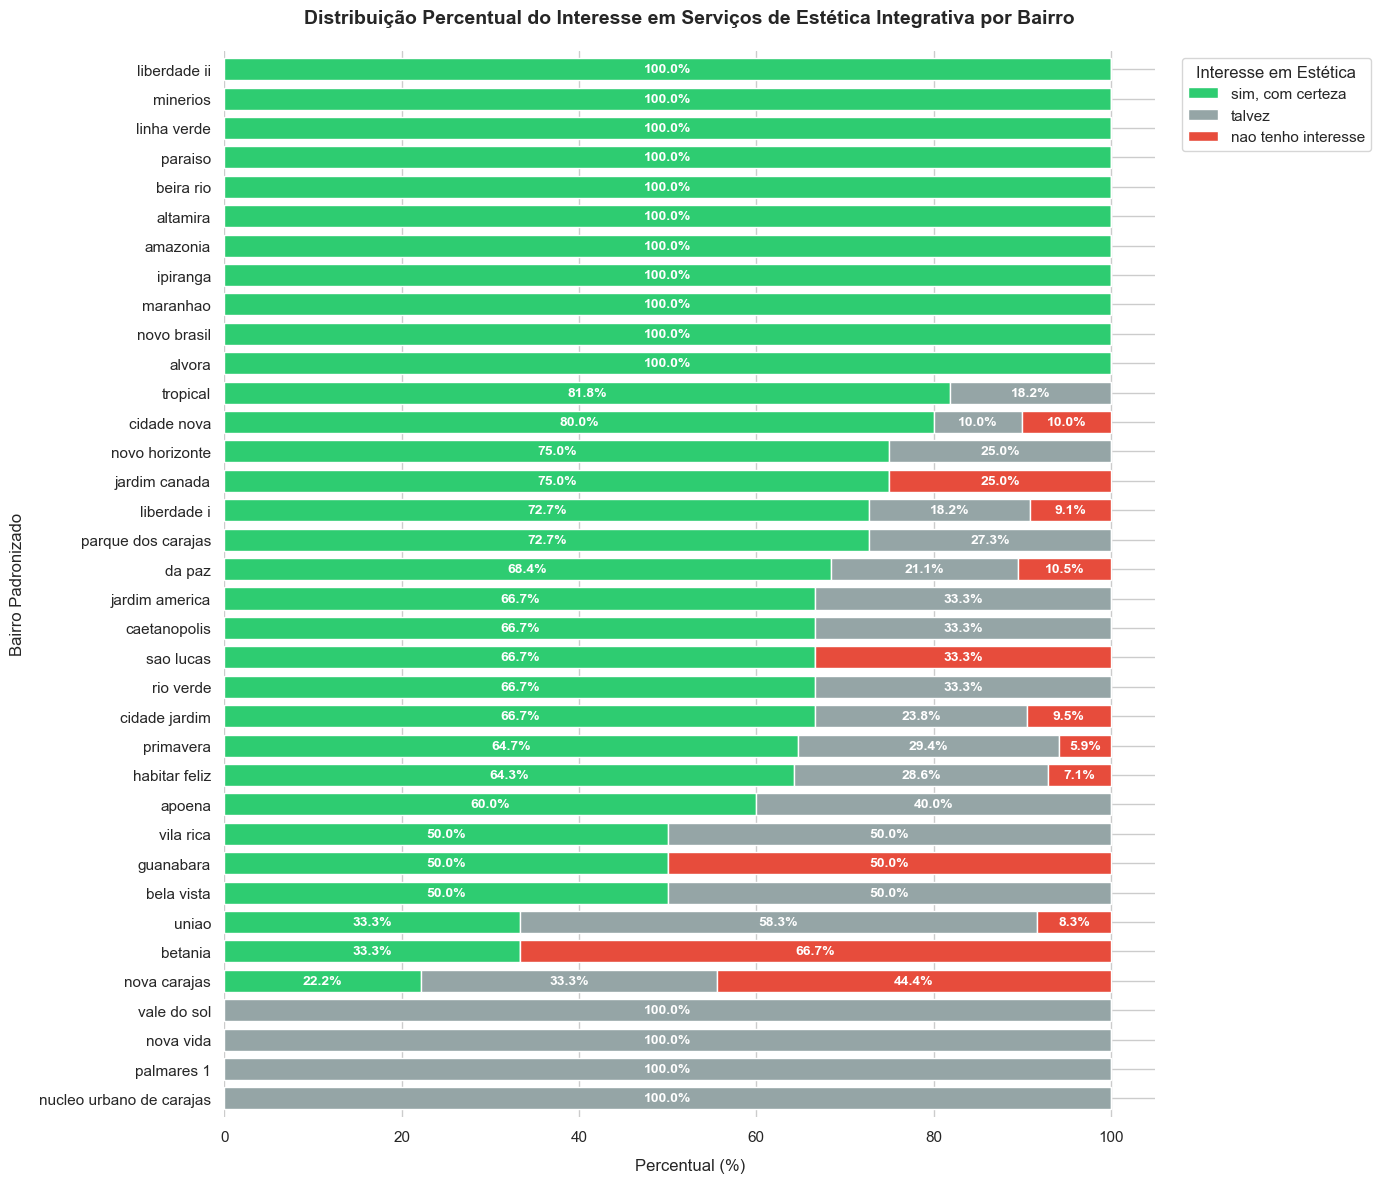

In [142]:
### 7.2. ANÁLISE VISUAL E PLOTAGEM DE GRÁFICOS ###

## grafico analise de percentual de interesse por estetica

## configura o estilo visual do grafico
sns.set_theme(style="whitegrid")

## garante que as colunas de interesse sigam uma ordem visual logica no grafico: 
## aa esquerda para a direita (ou base para o topo): nao -> talvez -> sim
ordem_respostas = ['nao tenho interesse', 'talvez', 'sim, com certeza']

## paleta de cores alinhada a ordem: vermelho (nao), cinza (talvez), verde (sim)
cores = ["#e74c3c", "#95a5a6", "#2ecc71"]

### GRÁFICO: ANÁLISE DE PERCENTUAL DE INTERESSE POR BAIRRO ###

## recria e ordena a tabela cruzada percentual
cross_bairro = pd.crosstab(df["bairro_padronizado"], df["interesse_estetica"], normalize="index") * 100

## forca a ordem exata no dataframe: o que vem primeiro fica encostado no eixo Y (esquerda)
ordem_estrita = ['sim, com certeza', 'talvez', 'nao tenho interesse']
cross_bairro = cross_bairro.reindex(columns=ordem_estrita, fill_value=0)

## ordena os bairros: deixa os bairros com 100% de "sim" no topo do grafico
if 'sim, com certeza' in cross_bairro.columns:
    cross_bairro = cross_bairro.sort_values(by="sim, com certeza", ascending=True)

### PALETA DE CORES SINCRONIZADA COM A ORDEM ACIMA ###

## verde para 'sim, com certeza', cinza para 'talvez', vermelho para 'nao tenho interesse'
cores_sincronizadas = ["#2ecc71", "#95a5a6", "#e74c3c"]  

## plota as barras horizontais empilhadas
ax_bairro = cross_bairro.plot(
    kind="barh", 
    stacked=True, 
    color=cores_sincronizadas, 
    figsize=(14, 12), 
    width=0.75
)

### ADICIONA OS RÓTULOS DE PORCENTAGEM DENTRO DAS BARRAS ###
for container in ax_bairro.containers:
    # cria os rotulos formatados (ex: 45.2%). se o valor for 0, deixa em branco ''
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 0 else '' for v in container]
    
    # plota os textos centralizados dentro de cada segmento da barra
    ax_bairro.bar_label(
        container, 
        labels=labels, 
        label_type='center', 
        color='white',       # cor do texto branca para dar contraste
        fontsize=10, 
        fontweight='bold'
    )

    
plt.title(
    "Distribuição Percentual do Interesse em Serviços de Estética Integrativa por Bairro",
    fontsize=14,
    pad=20,
    fontweight="bold",
)
plt.xlabel("Percentual (%)", fontsize=12, labelpad=10)
plt.ylabel("Bairro Padronizado", fontsize=12, labelpad=10)
plt.xlim(0, 105)              # estendido para 105 para garantir que a borda direita nao corte a barra de 100%


## força a legenda a exibir exatamente na mesma sequencia das barras
plt.legend(
    title="Interesse em Estética",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
    title_fontsize=12,
)

## remove bordas desnecessarias para o visual clean
sns.despine(left=True, bottom=True)
plt.tight_layout()

## salva o grafico corrigido na pasta do seu projeto
plt.savefig("grafico_bairro_interesse.png", dpi=300, bbox_inches='tight')
plt.show()  

--- Categorias de Renda Cadastradas ---
<StringArray>
[     '1 a 3 salarios minimos', 'acima de 5 salarios minimos',
      '3 a 5 salarios minimos',        'ate 1 salario minimo']
Length: 4, dtype: str

--- Tabela Percentual Ordenada: Renda x Interesse ---


interesse_estetica,"sim, com certeza",talvez,nao tenho interesse
renda,,,
ate 1 salario minimo,69.70,27.27,3.03
1 a 3 salarios minimos,57.14,24.68,18.18
3 a 5 salarios minimos,75.68,21.62,2.70
acima de 5 salarios minimos,71.70,24.53,3.77


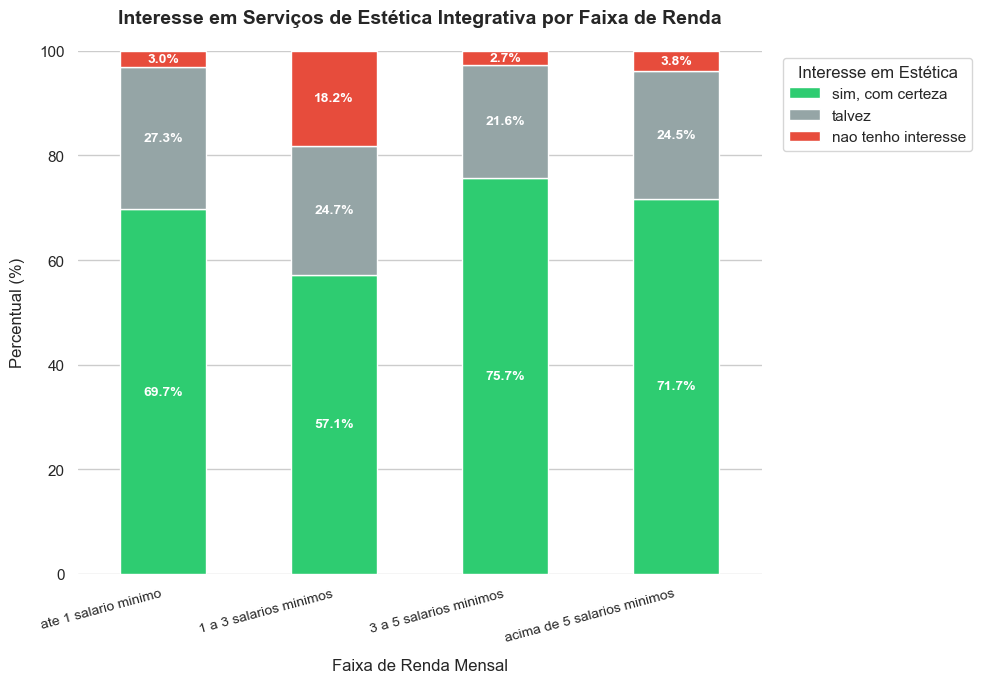

In [143]:
### 7.2.1. ANÁLISE VISUAL: INTERESSE EM ESTÉTICA POR FAIXA DE RENDA ###

print("--- Categorias de Renda Cadastradas ---")
print(df['renda'].unique())

cross_renda = pd.read_str_or_dynamic_if_needed = pd.crosstab(df['renda'], df['interesse_estetica'], normalize='index') * 100

## força a ordem logica das faixas de renda e das respostas
ordem_renda = [
    "ate 1 salario minimo",
    "1 a 3 salarios minimos",
    "3 a 5 salarios minimos",
    "acima de 5 salarios minimos"
]

## forca a ordem estrita no dataframe: o que vem primeiro fica na base da barra
ordem_estrita = ['sim, com certeza', 'talvez', 'nao tenho interesse']
cross_renda = cross_renda.reindex(index=ordem_renda, columns=ordem_estrita, fill_value=0)

print("\n--- Tabela Percentual Ordenada: Renda x Interesse ---")
display(cross_renda.round(2))

### PALETA DE CORES SINCRONIZADA COM A ORDEM ACIMA ###
## verde para 'sim, com certeza', cinza para 'talvez', vermelho para 'nao tenho interesse'
cores_sincronizadas = ["#2ecc71", "#95a5a6", "#e74c3c"]  

## plotar o grafico (barras verticais empilhadas)
ax_renda = cross_renda.plot(
    kind="bar", 
    stacked=True, 
    color=cores_sincronizadas, 
    figsize=(10, 7), 
    width=0.5
)

### ADICIONA RÓTULOS DE PORCENTAGEM DENTRO DAS BARRAS ###
for container in ax_renda.containers:
    # filtra valores maiores que zero para nao renderizar textos encavalados
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax_renda.bar_label(
        container, 
        labels=labels, 
        label_type='center', 
        fontsize=10, 
        color='white', 
        fontweight='bold'
    )

## ajustes academicos de titulos e eixos
plt.title("Interesse em Serviços de Estética Integrativa por Faixa de Renda", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Faixa de Renda Mensal", fontsize=12, labelpad=10)
plt.ylabel("Percentual (%)", fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right', fontsize=10) 
plt.ylim(0, 100)

## configura a legenda para fora do grafico
plt.legend(
    title="Interesse em Estética", 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    fontsize=11, 
    title_fontsize=12
)

sns.despine(left=True, bottom=True)
plt.tight_layout()

## salva a imagem corrigida com alta resolucao
plt.savefig("grafico_renda_interesse.png", dpi=300, bbox_inches='tight')
plt.show()



--- Tabela Percentual: Gênero x Interesse ---


interesse_estetica,"sim, com certeza",talvez,nao tenho interesse
genero,,,
feminino,79.17,16.67,4.17
masculino,55.34,31.07,13.59
prefiro nao informar,0.00,100.00,0.00


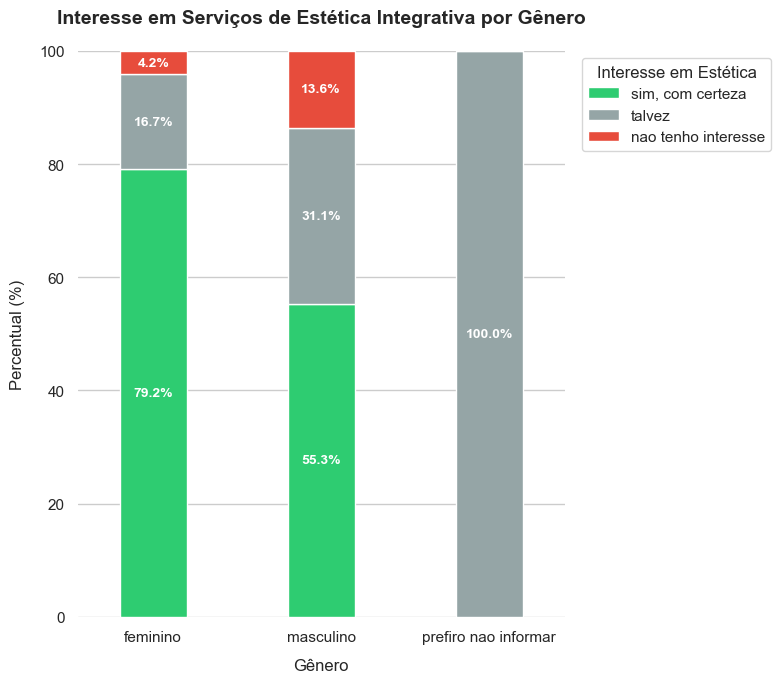

In [144]:
### 7.2.2. ANÁLISE VISUAL: INTERESSE EM ESTÉTICA POR GÊNERO ###

cross_genero = pd.crosstab(df["genero"], df["interesse_estetica"], normalize="index") * 100

## força a ordem estrita no dataframe e sincroniza cores
cross_genero = cross_genero.reindex(columns=ordem_estrita, fill_value=0)

print("\n--- Tabela Percentual: Gênero x Interesse ---")
display(cross_genero.round(2))

## plotar o grafico (barras verticais empilhadas)
ax_gen = cross_genero.plot(
    kind="bar", stacked=True, color=cores_sincronizadas, figsize=(8, 7), width=0.4
)

## adiciona rotulos de porcentagem dentro das barras
for container in ax_gen.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax_gen.bar_label(container, labels=labels, label_type='center', fontsize=10, color='white', fontweight='bold')

plt.title(
    "Interesse em Serviços de Estética Integrativa por Gênero",
    fontsize=14,
    pad=20,
    fontweight="bold",
)
plt.xlabel("Gênero", fontsize=12, labelpad=10)
plt.ylabel("Percentual (%)", fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11) 
plt.ylim(0, 100)

plt.legend(
    title="Interesse em Estética",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("grafico_genero_interesse.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 50 + "\n")


--- Categorias de Idade Cadastradas Realmente ---
<StringArray>
['26 a 35 anos', '36 a 45 anos', '46 anos ou mais', '18 a 25 anos']
Length: 4, dtype: str

--- Tabela Percentual Corrigida: Faixa Etária x Interesse ---


interesse_estetica,"sim, com certeza",talvez,nao tenho interesse
faixa_etaria,,,
18 a 25 anos,83.33,13.33,3.33
26 a 35 anos,61.73,29.63,8.64
36 a 45 anos,67.35,22.45,10.20
46 anos ou mais,62.50,25.00,12.50


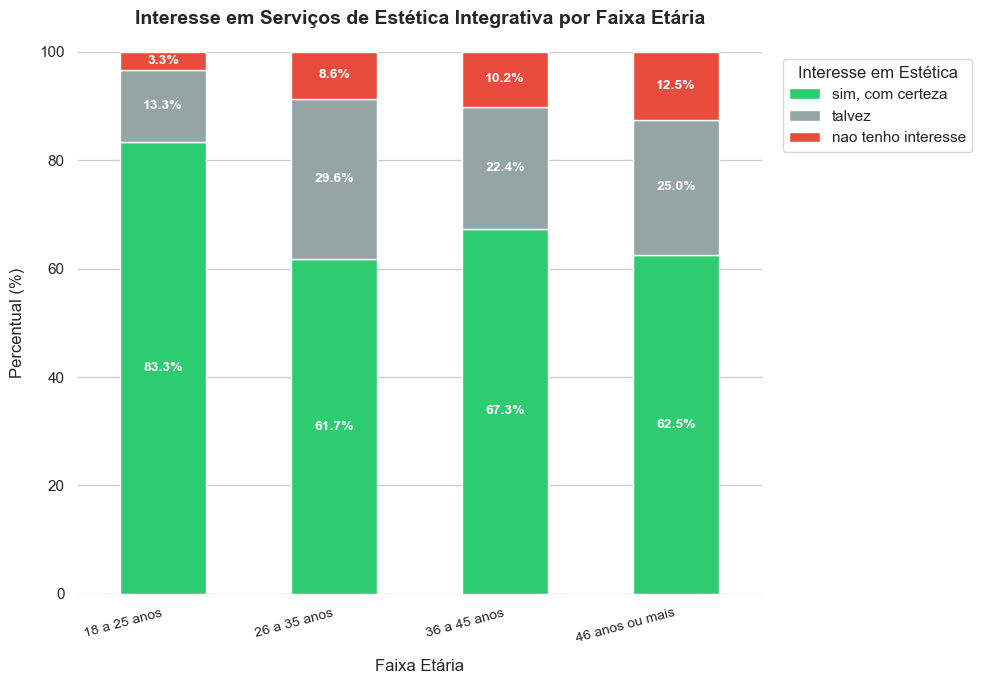

In [145]:
### 7.2.3. ANÁLISE VISUAL: INTERESSE EM ESTÉTICA POR FAIXA ETÁRIA ###

print("--- Categorias de Idade Cadastradas Realmente ---")
print(df['faixa_etaria'].unique())

## cria a tabela cruzada original sem forçar as linhas manualmente
cross_etaria = pd.crosstab(df["faixa_etaria"], df["interesse_estetica"], normalize="index") * 100

## força apenas a ordem das colunas (sim, talvez, nao)
cross_etaria = cross_etaria.reindex(columns=ordem_estrita, fill_value=0)

## ordenacao automatica: organiza as idades do menor para o maior numero
cross_etaria = cross_etaria.sort_index()

print("\n--- Tabela Percentual Corrigida: Faixa Etária x Interesse ---")
display(cross_etaria.round(2))

## plotar o grafico (barras verticais empilhadas)
ax_et = cross_etaria.plot(
    kind="bar", stacked=True, color=cores_sincronizadas, figsize=(10, 7), width=0.5
)

## adiciona rotulos de porcentagem dentro das barras
for container in ax_et.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax_et.bar_label(container, labels=labels, label_type='center', fontsize=10, color='white', fontweight='bold')

plt.title(
    "Interesse em Serviços de Estética Integrativa por Faixa Etária",
    fontsize=14,
    pad=20,
    fontweight="bold",
)
plt.xlabel("Faixa Etária", fontsize=12, labelpad=10)
plt.ylabel("Percentual (%)", fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha="right", fontsize=10)
plt.ylim(0, 100)

plt.legend(
    title="Interesse em Estética",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("grafico_faixa_etaria_interesse.png", dpi=300, bbox_inches="tight")
plt.show()

In [146]:
### 7.3. ANÁLISE AVANÇADA: PERFIL COMBINADO DE MICRO-MERCADO POR BAIRRO ###
print("\n" + "="*50 + "\n--- Iniciando Seção 7.3: Perfil Combinado ---")

# Agrupa a base usando os nomes exatos das colunas padronizadas do seu script
perfil_combinado = df.groupby([
    'bairro_padronizado', 
    'renda', 
    'interesse_estetica', 
    'usa_estetica', 
    'clinica_perto'
]).size().reset_index(name='quantidade_respondentes')

# Ordena de forma lógica para priorizar os bairros com maior volume de dados
perfil_combinado = perfil_combinado.sort_values(by=['bairro_padronizado', 'quantidade_respondentes'], ascending=[True, False])
display(perfil_combinado.head(10))


--- Iniciando Seção 7.3: Perfil Combinado ---


,bairro_padronizado,renda,interesse_estetica,usa_estetica,clinica_perto,quantidade_respondentes
3,altamira,ate 1 salario minimo,"sim, com certeza",nao,sim,3
0,altamira,1 a 3 salarios minimos,"sim, com certeza",nao,sim,1
1,altamira,acima de 5 salarios minimos,"sim, com certeza",nao,sim,1
2,altamira,acima de 5 salarios minimos,"sim, com certeza",sim,nao,1
4,altamira,ate 1 salario minimo,"sim, com certeza",sim,sim,1
5,alvora,acima de 5 salarios minimos,"sim, com certeza",sim,sim,1
6,amazonia,1 a 3 salarios minimos,"sim, com certeza",sim,sim,1
8,apoena,acima de 5 salarios minimos,"sim, com certeza",sim,sim,2
7,apoena,3 a 5 salarios minimos,"sim, com certeza",nao,sim,1
9,apoena,acima de 5 salarios minimos,talvez,nao,sim,1



--- Iniciando Análise Avançada de Perfis ---

--- % de Interesse em Clínica Perto por Faixa de Renda ---


,tx_quer_clinica_perto
renda,
ate 1 salario minimo,93.94
1 a 3 salarios minimos,81.82
3 a 5 salarios minimos,91.89
acima de 5 salarios minimos,83.02



--- % de Interesse em Serviços por Faixa de Renda ---


,Area De Sobrancelha,Depilacao A Laser,Harmonizacao Facial,Limpeza De Pele,Manicure,Manicure / Pedicure / Cabelo,Procedimentocorporais,Procedimentominimamente Invasivos,Terapiaintegrativarelaxamento Bem Estar,Tratamento de Enzimas (Gordura),Tratamento Faciaianti Idade Rejuvenescimento
renda,,,,,,,,,,,
ate 1 salario minimo,3.03,0.0,27.27,72.73,0.00,0.0,27.27,3.03,39.39,3.03,30.30
1 a 3 salarios minimos,0.00,1.3,15.58,55.84,0.00,1.3,32.47,24.68,45.45,0.00,40.26
3 a 5 salarios minimos,0.00,0.0,29.73,70.27,0.00,0.0,51.35,37.84,62.16,0.00,51.35
acima de 5 salarios minimos,0.00,0.0,33.96,73.58,1.89,0.0,35.85,35.85,62.26,0.00,50.94


<Figure size 1400x1000 with 0 Axes>

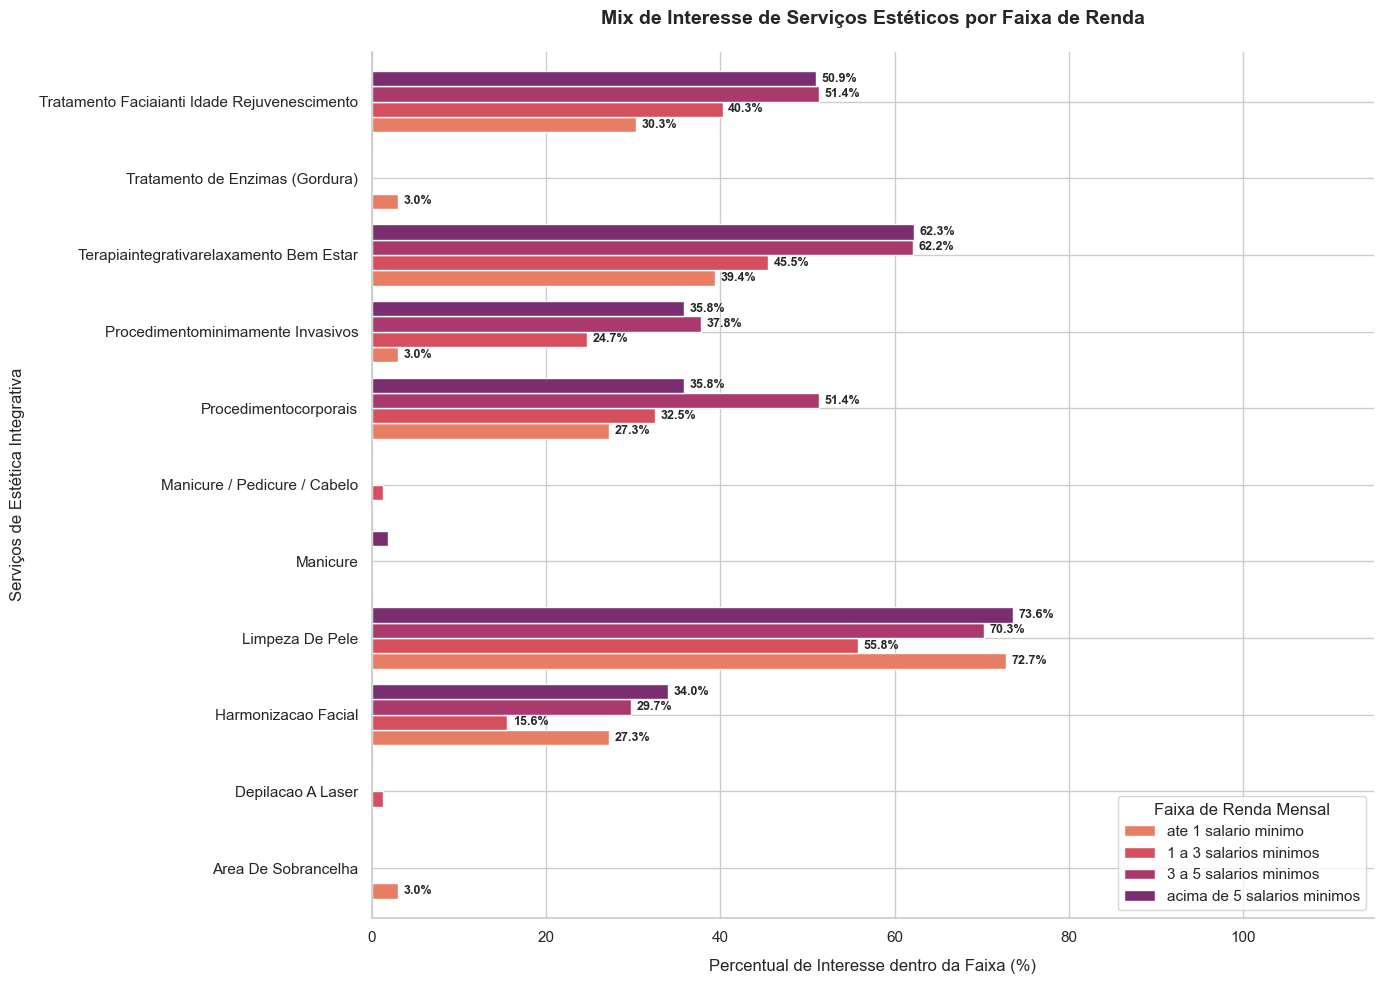

In [147]:
### 7.3.1. ANÁLISE AVANÇADA: SEGMENTAÇÃO DE PERFIL E PERSONAS (RENDA x DESEJOS) ###

print("\n" + "="*50 + "\n--- Iniciando Análise Avançada de Perfis ---")

# Garante a ordenação lógica da renda para os cruzamentos
ordem_renda = [
    "ate 1 salario minimo",
    "1 a 3 salarios minimos",
    "3 a 5 salarios minimos",
    "acima de 5 salarios minimos"
]

# Tabela Cruzada: Renda x Desejo de Clínica Perto (Média da dummy)
cross_renda_perto = df.groupby('renda')['d_clinica_perto'].mean().reindex(ordem_renda) * 100
print("\n--- % de Interesse em Clínica Perto por Faixa de Renda ---")
display(cross_renda_perto.to_frame(name='tx_quer_clinica_perto').round(2))

# Mapeamento do Mix de Serviços por Faixa de Renda
colunas_s_atuais = [col for col in df.columns if col.startswith('s_')]
servicos_por_renda = df.groupby('renda')[colunas_s_atuais].mean().reindex(ordem_renda) * 100

# TRATAMENTO TEXTUAL AUTOMÁTICO: Remove o 's_' e os sublinhados do eixo Y
nomes_limpos_servicos = {
    col: col.replace('s_', '').replace('_', ' ').title() 
    for col in servicos_por_renda.columns
}

# AJUSTES MANUAIS: Encurta termos excessivamente longos para não quebrar o layout
ajustes_manuais = {
    "Procedimentos Esteticos Injetaveis Ex Toxina Botulinica Preenchedores Bioestimuladores": "Procedimentos Injetáveis Avançados",
    "Terapias Integrativas Relaxamento Bem Estar": "Terapias Integrativas / Bem-Estar",
    "Tratamento De Enzima Para Retirar Gordura": "Tratamento de Enzimas (Gordura)",
    "Tratamento Faciais Anti Idade Rejuvenescimento": "Tratamentos Faciais Anti-Idade",
    "Manicure E Pedicure Corte Cabelo": "Manicure / Pedicure / Cabelo"
}

# Aplica as limpezas de texto sequencialmente
servicos_por_renda = servicos_por_renda.rename(columns=nomes_limpos_servicos)
servicos_por_renda = servicos_por_renda.rename(columns=ajustes_manuais)

print("\n--- % de Interesse em Serviços por Faixa de Renda ---")
display(servicos_por_renda.round(2))

# PLOTAGEM DO MIX DE SERVIÇOS COM PALETA SEQUENCIAL CORRIGIDA
servicos_transpostos = servicos_por_renda.T
cores_perfil = sns.color_palette("flare", n_colors=len(ordem_renda))

plt.figure(figsize=(14, 10))
ax_mix = servicos_transpostos.plot(
    kind='barh', 
    figsize=(14, 10), 
    width=0.8,
    color=cores_perfil
)

# Rótulos de dados formatados nas pontas das barras
for container in ax_mix.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 3 else '' for v in container]
    ax_mix.bar_label(container, labels=labels, label_type='edge', fontsize=9, fontweight='bold', padding=4)

plt.title("Mix de Interesse de Serviços Estéticos por Faixa de Renda", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Percentual de Interesse dentro da Faixa (%)", fontsize=12, labelpad=10)
plt.ylabel("Serviços de Estética Integrativa", fontsize=12, labelpad=10)
plt.xlim(0, 115)
plt.legend(title="Faixa de Renda Mensal", loc="lower right", fontsize=11, title_fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig("grafico_mix_servicos_renda.png", dpi=300, bbox_inches='tight')
plt.show()



--- Analisando Público-Alvo Combinado vs Interesse ---


<Figure size 1400x700 with 0 Axes>

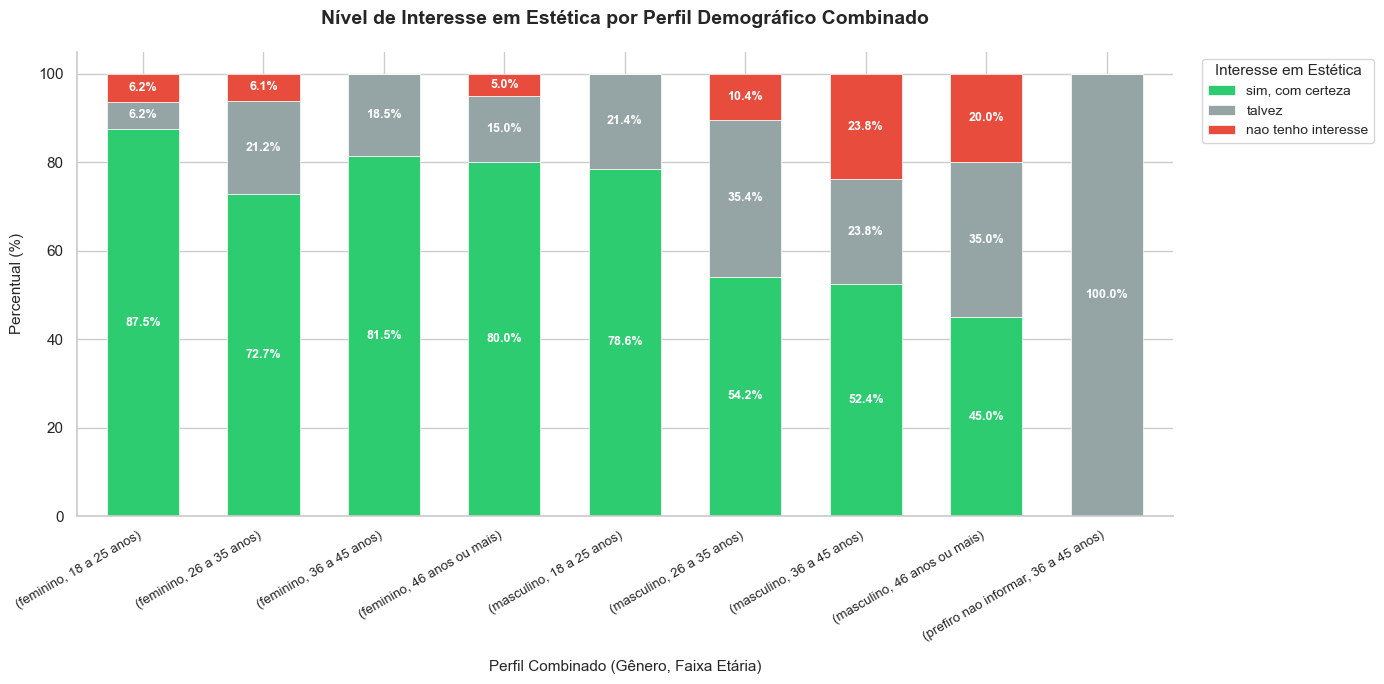

In [148]:
### 7.4. CRUZAMENTO DEMOGRÁFICO AVANÇADO (GÊNERO + IDADE) vs INTERESSE ###

print("\n--- Analisando Público-Alvo Combinado vs Interesse ---")

# Cria a tabela cruzada multi-index usando a ordem estrita de respostas
publico_interesse = pd.crosstab([df['genero'], df['faixa_etaria']], df['interesse_estetica'], normalize='index') * 100
publico_interesse = publico_interesse.reindex(columns=ordem_estrita, fill_value=0)

# Plotagem do gráfico de barras empilhadas (stacked)
plt.figure(figsize=(14, 7))
ax_pub = publico_interesse.plot(
    kind='bar', 
    stacked=True, 
    color=cores_sincronizadas, 
    figsize=(14, 7), 
    width=0.6,
    edgecolor='white', # Adiciona uma linha branca sutil separando os blocos
    linewidth=0.5
)

# LÓGICA DE INCLUSÃO DOS PERCENTUAIS DENTRO DAS BARRAS EMPILHADAS
# O loop percorre cada container (categoria de resposta) para ler as alturas e posições
for container in ax_pub.containers:
    # Calcula os rótulos: exibe o percentual se o bloco for maior que 3% (evita sobreposição)
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in container]
    
    # Adiciona os rótulos exatamente no centro de cada sub-bloco empilhado
    ax_pub.bar_label(
        container, 
        labels=labels, 
        label_type='center', # Força o texto a ficar centralizado DENTRO do bloco
        fontsize=9, 
        fontweight='bold', 
        color='white' # Texto em branco para dar alto contraste sobre as cores
    )

# Ajustes estéticos de layout e títulos
plt.title("Nível de Interesse em Estética por Perfil Demográfico Combinado", pad=20, fontsize=14, fontweight='bold')
plt.xlabel("Perfil Combinado (Gênero, Faixa Etária)", fontsize=11, labelpad=12)
plt.ylabel("Percentual (%)", fontsize=11, labelpad=10)
plt.ylim(0, 105)

# Rotaciona e alinha os nomes das categorias do eixo X de forma limpa
plt.xticks(rotation=30, ha='right', fontsize=9.5)
plt.legend(title="Interesse em Estética", bbox_to_anchor=(1.02, 1), loc='upper left', title_fontsize=11, fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig("grafico_perfil_demografico_interesse.png", dpi=300, bbox_inches='tight')
plt.show()



--- Analisando Fatores de Influência por Renda ---


<Figure size 1400x850 with 0 Axes>

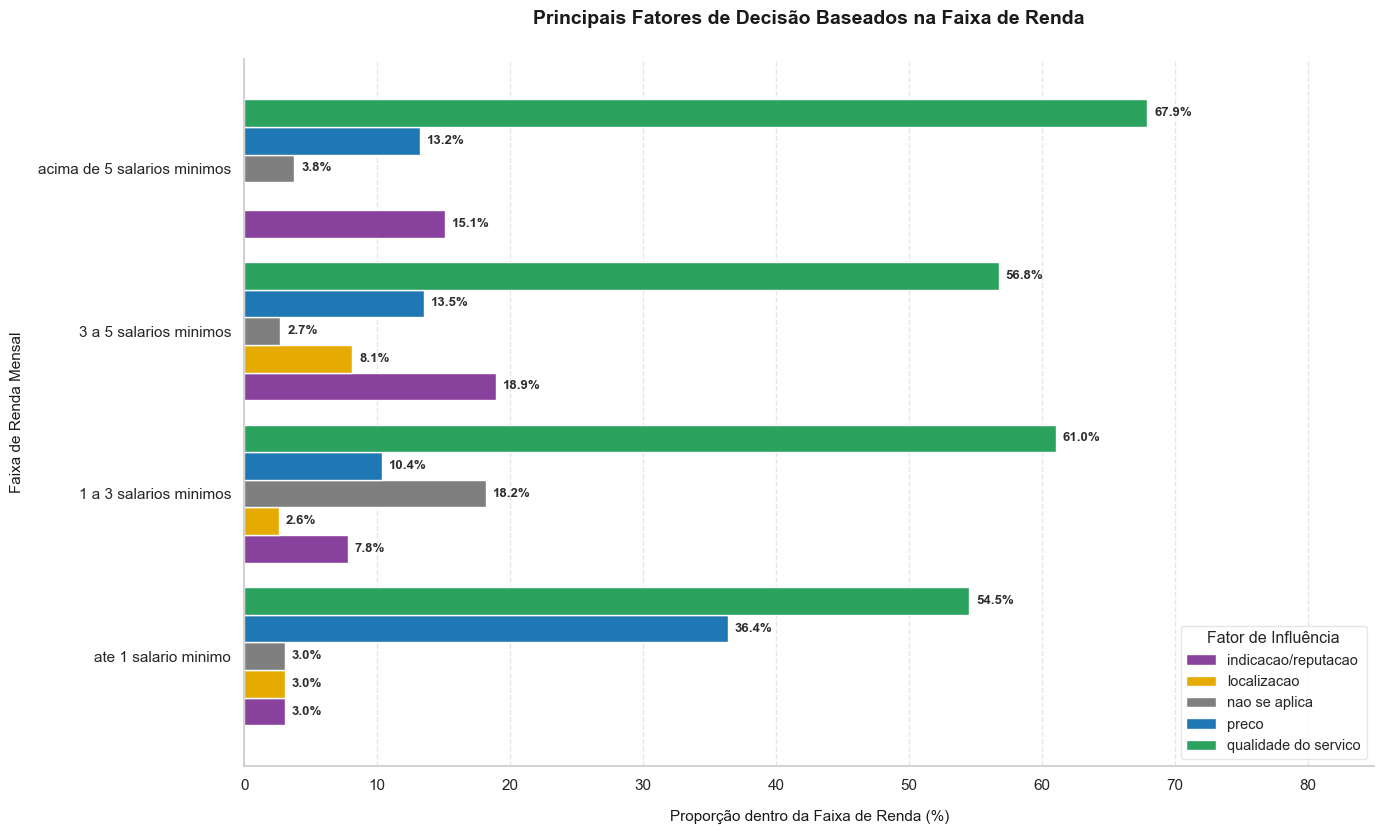

In [149]:
### 7.5. ANÁLISE DOS FATORES DE DECISÃO DOMINANTES POR RENDA ###

print("\n--- Analisando Fatores de Influência por Renda ---")

# Tabela cruzada de fatores de influência ordenada de forma lógica
fator_renda = pd.crosstab(df['renda'], df['fator_influencia'], normalize='index') * 100
fator_renda = fator_renda.reindex(index=ordem_renda, fill_value=0)

# DICIONÁRIO MAPA DE CORES
mapa_cores_fatores = {
    "qualidade do servico": "#2ca25f",    # Verde - Super Importante
    "preco": "#1f77b4",                   # Azul - Fator Econômico Racional
    "indicacao/reputacao": "#88419c",     # Roxo Orquídea - Estética/Conexão
    "localizacao": "#e6ab02",             # Amarelo Mostarda - Relevância Moderada
    "nao se aplica": "#7f7f7f"            # Cinza - Neutro/Sem destaque visual
}

# Garante que as cores sigam a ordem exata das colunas resultantes da tabela cruzada
cores_ordenadas = [mapa_cores_fatores[col] for col in fator_renda.columns]

plt.figure(figsize=(14, 8.5))
ax_fat = fator_renda.plot(
    kind='barh', 
    stacked=False, 
    width=0.85, 
    figsize=(14, 8.5), 
    color=cores_ordenadas # Aplica o mapeamento estratégico de cores
)

# LÓGICA DE INCLUSÃO DOS PERCENTUAIS NA PONTA DE CADA BARRA
for container in ax_fat.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 1 else '' for v in container]
    
    ax_fat.bar_label(
        container, 
        labels=labels, 
        label_type='edge', 
        fontsize=9.5, 
        fontweight='bold', 
        padding=5,
        color='#2e2e2e'
    )

# Ajustes estéticos finais de layout
plt.title("Principais Fatores de Decisão Baseados na Faixa de Renda", pad=25, fontsize=14, fontweight='bold', color='#1a1a1a')
plt.xlabel("Proporção dentro da Faixa de Renda (%)", fontsize=11, labelpad=12, color='#1a1a1a')
plt.ylabel("Faixa de Renda Mensal", fontsize=11, labelpad=10, color='#1a1a1a')
plt.xlim(0, 85)

ax_fat.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax_fat.yaxis.grid(False)

plt.legend(title="Fator de Influência", loc="lower right", fontsize=10.5, title_fontsize=11.5, frameon=True, facecolor='white', edgecolor='#e0e0e0')

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig("grafico_fator_decisao_renda.png", dpi=300, bbox_inches='tight')
plt.show()



--- Analisando Critérios de Mobilidade e Disposição de Compra ---


<Figure size 1200x600 with 0 Axes>

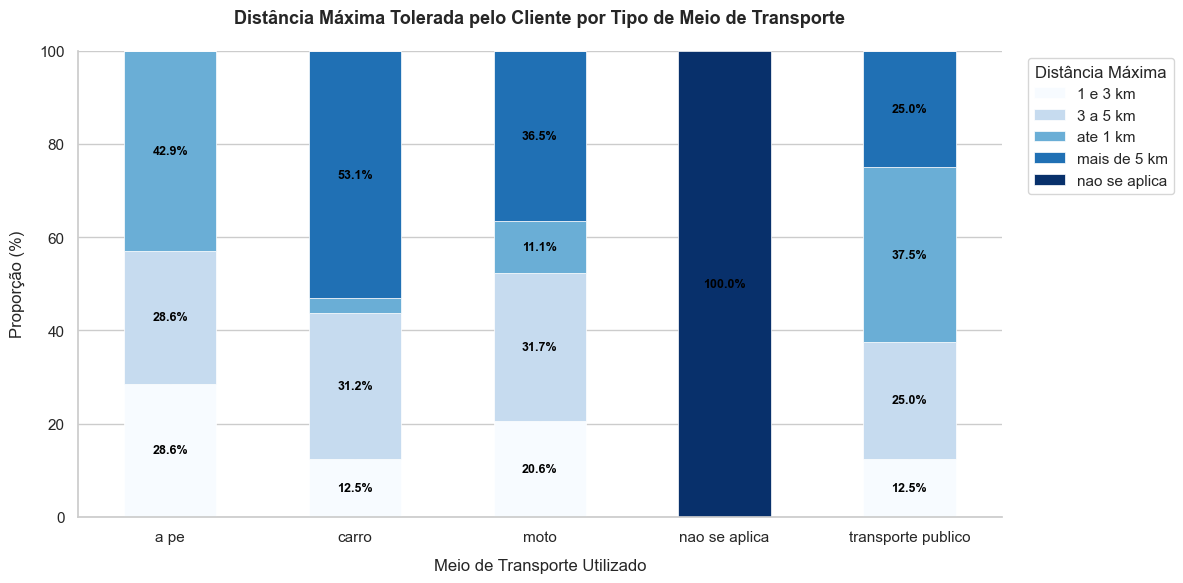

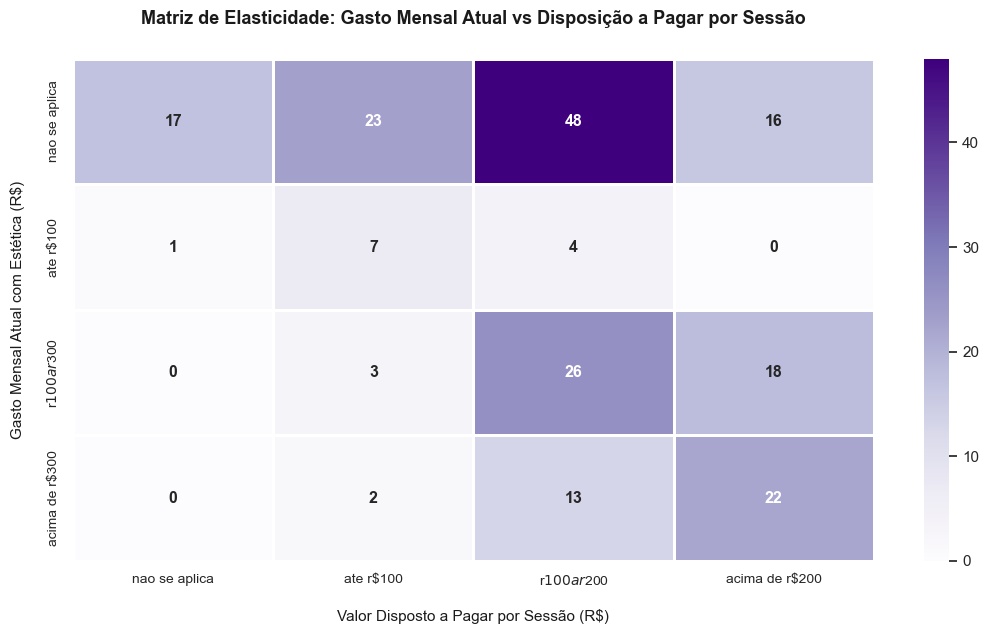

In [150]:
### 7.6. LOGÍSTICA DE DESLOCAMENTO E ELASTICIDADE DE PREÇO (GEOMARKETING) ###

print("\n--- Analisando Critérios de Mobilidade e Disposição de Compra ---")

# Cruzamento de Meio de Transporte vs Distância Máxima Tolerada
transporte_distancia = pd.crosstab(df['transporte'], df['dist_maxima'], normalize='index') * 100

# Plotagem da Mobilidade Urbana (Gráfico de Barras Empilhadas)
plt.figure(figsize=(12, 6))
ax_transp = transporte_distancia.plot(
    kind='bar', 
    stacked=True, 
    cmap='Blues', 
    figsize=(12, 6), 
    width=0.5,
    edgecolor='white',
    linewidth=0.5
)

for container in ax_transp.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 4 else '' for v in container]
    ax_transp.bar_label(container, labels=labels, label_type='center', fontsize=9, fontweight='bold', color='black')

plt.title("Distância Máxima Tolerada pelo Cliente por Tipo de Meio de Transporte", pad=20, fontsize=13, fontweight='bold')
plt.xlabel("Meio de Transporte Utilizado", labelpad=10)
plt.ylabel("Proporção (%)", labelpad=10)
plt.xticks(rotation=0) 
plt.legend(title="Distância Máxima", bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.savefig("grafico_logistica_transporte.png", dpi=300, bbox_inches='tight')
plt.show()


# Cruzamento de Orçamento: Gasto Atual em Estética vs Valor Disposto por Sessão
gasto_vs_disposto = pd.crosstab(df['gasto_estetica'], df['valor_disposto'])

# --- CORREÇÃO DA MATRIZ DO HEATMAP SEM PERDA DE DADOS (ORDENAÇÃO AUTOMÁTICA) ---
linhas_originais = list(gasto_vs_disposto.index)
colunas_originais = list(gasto_vs_disposto.columns)

def chave_ordenacao(texto):
    texto_lower = str(texto).lower().strip()
    if "nao" in texto_lower or "não" in texto_lower:
        return 0
    elif "ate" in texto_lower or "até" in texto_lower:
        return 1
    elif "100" in texto_lower:
        return 2
    elif "acima" in texto_lower:
        return 3
    return 4

ordem_linhas_correta = sorted(linhas_originais, key=chave_ordenacao)
ordem_colunas_correta = sorted(colunas_originais, key=chave_ordenacao)

# Aplica a reindexação de forma segura usando os textos exatos extraídos da planilha
gasto_vs_disposto_ordenado = gasto_vs_disposto.reindex(
    index=ordem_linhas_correta, 
    columns=ordem_colunas_correta, 
    fill_value=0
)

# Plotagem da Elasticidade de Preço Corrigida (Mapa de Calor / Heatmap)
plt.figure(figsize=(11, 6.5))
sns.heatmap(
    gasto_vs_disposto_ordenado, 
    annot=True,          
    fmt="d",             
    cmap="Purples",      
    linewidths=.8, 
    cbar=True,
    annot_kws={"weight": "bold", "size": 11.5}
)

plt.title("Matriz de Elasticidade: Gasto Mensal Atual vs Disposição a Pagar por Sessão", pad=25, fontsize=13, fontweight='bold', color='#1a1a1a')
plt.xlabel("Valor Disposto a Pagar por Sessão (R$)", labelpad=15, fontsize=11, color='#1a1a1a')
plt.ylabel("Gasto Mensal Atual com Estética (R$)", labelpad=15, fontsize=11, color='#1a1a1a')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig("grafico_elasticidade_preco.png", dpi=300, bbox_inches='tight')
plt.show()



In [151]:
### 7.7. CONSOLIDAÇÃO E EXPORTAÇÃO DOS RELATÓRIOS EM EXCEL ###
print("\n--- Iniciando Seção 7.7: Exportação dos Dados Comportamentais ---")

with pd.ExcelWriter("Relatorio_Completo_BI_Estetica.xlsx") as writer:
    perfil_combinado.to_excel(writer, sheet_name="Perfil_Combinado_Bairro", index=False)
    publico_interesse.to_excel(writer, sheet_name="Publico_vs_Interesse")
    fator_renda.to_excel(writer, sheet_name="Fatores_Decisao_Renda")
    transporte_distancia.to_excel(writer, sheet_name="Logistica_Transporte")
    gasto_vs_disposto.to_excel(writer, sheet_name="Elasticidade_Preco")

print("✓ Sucesso! O arquivo 'Relatorio_Completo_BI_Estetica.xlsx' foi gerado.")
print("Pronto para prosseguir para a Seção 8: Modelagem MCDA.")
print("="*50 + "\n")


--- Iniciando Seção 7.7: Exportação dos Dados Comportamentais ---
✓ Sucesso! O arquivo 'Relatorio_Completo_BI_Estetica.xlsx' foi gerado.
Pronto para prosseguir para a Seção 8: Modelagem MCDA.



In [152]:
### 8. MODELAGEM MCDA - MDS (METODO DE DECISAO POR SOMA PONDERADA SIMPLES e MAVT (TEORIA DE VALOR DE MULTIPLOS ATRIBUTOS - MODELO ADITIVO): ATRIBUIÇÃO DE PESOS E RANKING FINAL DE BAIRROS ###

## Técnica utilizada Análise Multicritério de Decisão (MCDA) MAVT (Soma Ponderada Simples / Modelo Aditivo).. 

## carrega a matriz consolidada que salvamos anteriormente
df_mcda = pd.read_excel(r"C:\Users\luish\Downloads\Desenvolvimento TCC\TCC\02 - Dados Tratados\matriz_final_mcda_bairros.xlsx")

## definicao dos pesos dos criterios (a soma de todos deve dar 1.0 ou 100%)
pesos_criterios = {
    'tx_int_pa': 0.18,      # 18% de peso para a taxa geral de interesse
    'tx_cl_pert': 0.09,      # 9% de peso para o desejo de ter a clínica perto da residência
    's_limp_pl': 0.14,       # 14% de peso para interesse em limpeza de pele
    's_pcd_inv': 0.14,       # 14% de peso para procedimentos invasivos/injetáveis
    's_terapias': 0.14,      # 14% de peso para terapias integrativas
    's_ptc_corp': 0.12,      # 12% de peso para tratamentos corporais/massagem
    's_ptc_face': 0.11,      # 11% de peso para tratamentos faciais/peeling
    's_depil_ls': 0.08,      # 8% de peso para depilação a laser
   }

## normalizacao dos dados (transforma tudo para escala de 0 a 1)
df_norm = matriz_mcda.copy()
colunas_para_calcular = list(pesos_criterios.keys())

for col in colunas_para_calcular:
    max_val = matriz_mcda[col].max()
    min_val = matriz_mcda[col].min()
    
    # evita divisao por zero caso o criterio tenha valores todos iguais
    if max_val - min_val > 0:
        df_norm[col] = (matriz_mcda[col] - min_val) / (max_val - min_val)
    else:
        df_norm[col] = 0

## calculo da pontuacao final (soma ponderada)
matriz_mcda['pontuacao_mcda'] = 0.0
for col, peso in pesos_criterios.items():
    matriz_mcda['pontuacao_mcda'] += df_norm[col] * peso

## multiplica por 100 para virar uma nota de 0 a 100
matriz_mcda['pontuacao_mcda'] = (matriz_mcda['pontuacao_mcda'] * 100).round(2)

## ordena o ranking do melhor para o pior bairro
matriz_mcda = matriz_mcda.sort_values(by='pontuacao_mcda', ascending=False).reset_index(drop=True)
matriz_mcda['posicao_ranking'] = matriz_mcda.index + 1

print("--- Lógica Matemática do MCDA Concluída! ---")
display(matriz_mcda[['posicao_ranking', 'bairro_padronizado', 'pontuacao_mcda', 'tot_entrv', 'tx_int_pa', 'tx_cl_pert']].head(15))

## salva a matriz para abrir no QGIS
matriz_mcda.to_excel("matriz_final_mcda_bairros.xlsx", index=False)
print("Arquivo 'matriz_final_mcda_bairros.xlsx' atualizado com a nota do MCDA!")

--- Lógica Matemática do MCDA Concluída! ---


,posicao_ranking,bairro_padronizado,pontuacao_mcda,tot_entrv,tx_int_pa,tx_cl_pert
0,1,primavera,69.66,17,64.71,94.12
1,2,da paz,65.64,19,68.42,78.95
2,3,cidade jardim,63.56,21,66.67,85.71
3,4,habitar feliz,61.41,14,64.29,92.86
4,5,tropical,52.99,11,81.82,90.91
5,6,parque dos carajas,50.60,11,72.73,81.82
6,7,beira rio,44.43,6,100.00,100.00
7,8,altamira,43.38,7,100.00,85.71
8,9,cidade nova,40.52,10,80.00,80.00
9,10,novo horizonte,39.81,4,75.00,100.00


Arquivo 'matriz_final_mcda_bairros.xlsx' atualizado com a nota do MCDA!


In [153]:
### 8.1. PREPARAÇÃO DE DADOS DE RENDA PARA O MAPA QGIS ###
print("\n--- Estruturando Dados de Renda para Integração Espacial ---")

# Cria colunas dummy para cada faixa de renda para contar a ocorrência por bairro
dummies_renda = pd.get_dummies(df['renda'], prefix='r')

# Une as dummies de renda com a coluna do bairro padronizado
df_renda_bairro = pd.concat([df['bairro_padronizado'], dummies_renda], axis=1)

# Agrupa por bairro somando a quantidade de pessoas em cada faixa de renda
mapa_renda_bairros = df_renda_bairro.groupby('bairro_padronizado').sum().reset_index()

# Calcula o total de respondentes por bairro para descobrir a proporção interna
colunas_r = [col for col in mapa_renda_bairros.columns if col.startswith('r_')]
mapa_renda_bairros['tot_renda'] = mapa_renda_bairros[colunas_r].sum(axis=1)

# Transforma os valores absolutos em taxas percentuais (%) por bairro (essencial para mapas)
for col in colunas_r:
    nome_taxa = col.replace('r_', 'tx_r_')
    # Limita o nome a 10 caracteres para compatibilidade estrita com o formato Shapefile do QGIS
    nome_curto = nome_taxa[:10] 
    mapa_renda_bairros[nome_curto] = ((mapa_renda_bairros[col] / mapa_renda_bairros['tot_renda']) * 100).round(2)

# Remove as colunas temporárias absolutas para deixar o arquivo limpo
mapa_renda_qgis = mapa_renda_bairros.drop(columns=colunas_r)

# Salva o arquivo pronto para o Join no QGIS
mapa_renda_qgis.to_excel("dados_renda_para_qgis.xlsx", index=False)
print("Arquivo 'dados_renda_para_qgis.xlsx' exportado com sucesso!")



--- Estruturando Dados de Renda para Integração Espacial ---
Arquivo 'dados_renda_para_qgis.xlsx' exportado com sucesso!
